## Redes Neuronales Densas (DNN)

In [7]:
# ---- Configuración de dispositivo: CPU o GPU ----
usar_gpu = False  # Cambia a False para forzar CPU

import os
import tensorflow as tf

if usar_gpu:
    # Usa GPU si existe (GPU 0)
    os.environ["CUDA_VISIBLE_DEVICES"] = "0"
else:
    # Fuerza uso de CPU ocultando las GPU
    os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

print(f"usar_gpu = {usar_gpu} (CUDA_VISIBLE_DEVICES={os.environ['CUDA_VISIBLE_DEVICES']})")


usar_gpu = False (CUDA_VISIBLE_DEVICES=-1)


In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

# cargar datos
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

# modelo CNN simple
model = models.Sequential([
    layers.Reshape((28,28,1), input_shape=(28,28)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=2)

d:\.venv\Lib\site-packages\keras\src\layers\reshaping\reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9496 - loss: 0.1718
Epoch 2/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9826 - loss: 0.0574


## CNN — clasificación de imágenes con MNIST

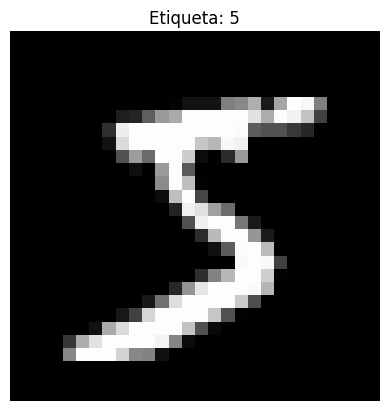

Epoch 1/2
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9339 - loss: 0.2315 - val_accuracy: 0.9747 - val_loss: 0.0955
Epoch 2/2
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9764 - loss: 0.0786 - val_accuracy: 0.9837 - val_loss: 0.0627
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9813 - loss: 0.0571
Accuracy en test: 0.9812999963760376


In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# Cargar datos
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalizar
X_train = X_train / 255.0
X_test = X_test / 255.0

# Mostrar una imagen
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Etiqueta: {y_train[0]}")
plt.axis("off")
plt.show()

# Modelo CNN simple
model = models.Sequential([
    layers.Reshape((28, 28, 1), input_shape=(28, 28)),
    layers.Conv2D(16, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(32, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# Entrenar
model.fit(X_train, y_train, epochs=2, validation_split=0.1)

# Evaluar
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy en test:", acc)

## RNN / LSTM — predicción simple de serie temporal

Epoch 1/5


d:\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4640
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3456
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2641
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1775
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0741 
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/stepWARNING:tensorflow:5 out of the last 5 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000024C17DC2520> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and

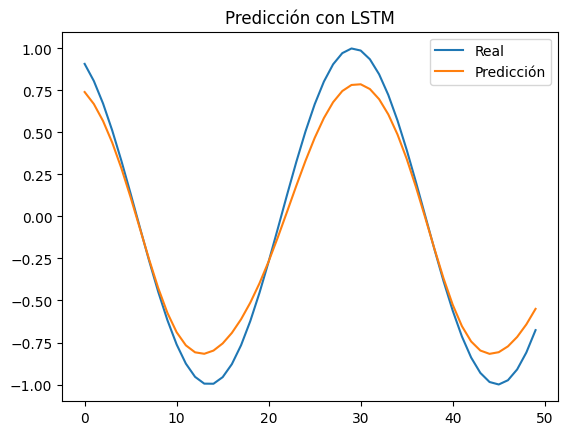

In [10]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Serie sintética
x = np.linspace(0, 100, 500)
serie = np.sin(x)

# Crear ventanas
window = 10
X, y = [], []
for i in range(len(serie) - window):
    X.append(serie[i:i+window])
    y.append(serie[i+window])

X = np.array(X)
y = np.array(y)

# Reformar para LSTM: [muestras, pasos de tiempo, features]
X = X.reshape((X.shape[0], X.shape[1], 1))

# Modelo LSTM
model = models.Sequential([
    layers.LSTM(32, input_shape=(window, 1)),
    layers.Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.fit(X, y, epochs=5, verbose=1)

# Predicción
pred = model.predict(X[:50])

plt.plot(y[:50], label="Real")
plt.plot(pred, label="Predicción")
plt.legend()
plt.title("Predicción con LSTM")
plt.show()

## Autoencoder — compresión / reconstrucción de imágenes

Epoch 1/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2836 - val_loss: 0.1951
Epoch 2/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1755 - val_loss: 0.1586
Epoch 3/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1490 - val_loss: 0.1396
Epoch 4/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1335 - val_loss: 0.1269
Epoch 5/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1229 - val_loss: 0.1180
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


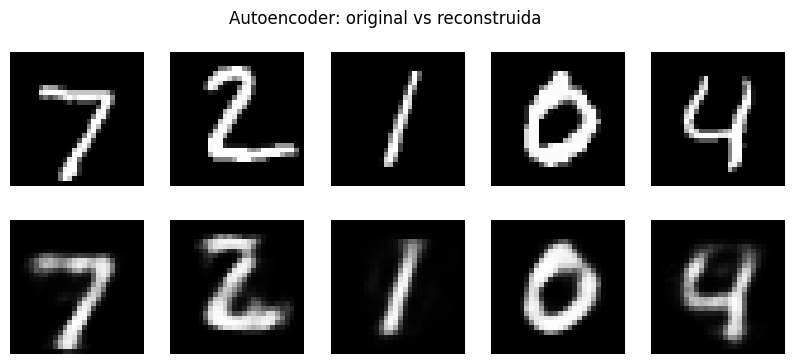

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# Cargar datos
(X_train, _), (X_test, _) = mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

# Aplanar imágenes
X_train = X_train.reshape((-1, 28*28))
X_test = X_test.reshape((-1, 28*28))

# Autoencoder simple
input_dim = 28 * 28
encoding_dim = 32

input_img = layers.Input(shape=(input_dim,))
encoded = layers.Dense(encoding_dim, activation='relu')(input_img)
decoded = layers.Dense(input_dim, activation='sigmoid')(encoded)

autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Entrenar
autoencoder.fit(X_train, X_train, epochs=5, batch_size=256, shuffle=True, validation_split=0.1)

# Reconstrucción
decoded_imgs = autoencoder.predict(X_test[:5])

# Mostrar originales vs reconstruidas
plt.figure(figsize=(10, 4))
for i in range(5):
    # original
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # reconstruida
    ax = plt.subplot(2, 5, i + 6)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("Autoencoder: original vs reconstruida")
plt.show()

## Transformer / modelo preentrenado — análisis de sentimiento

In [12]:
!pip -q install transformers

from transformers import pipeline

# Elegir dispositivo según usar_gpu definido arriba
# device=0 -> primera GPU, device=-1 -> CPU
device_id = 0 if usar_gpu else -1

classifier = pipeline(
    "sentiment-analysis",
    device=device_id
)

textos = [
    "Me encantó esta clase de redes neuronales",
    "Este contenido me confundió bastante",
    "La explicación estuvo clara y útil"
]

resultados = classifier(textos)

for texto, resultado in zip(textos, resultados):
    print(f"Texto: {texto}")
    print(f"Resultado: {resultado}")
    print("-" * 50)


No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Texto: Me encantó esta clase de redes neuronales
Resultado: {'label': 'POSITIVE', 'score': 0.9161191582679749}
--------------------------------------------------
Texto: Este contenido me confundió bastante
Resultado: {'label': 'POSITIVE', 'score': 0.8559314012527466}
--------------------------------------------------
Texto: La explicación estuvo clara y útil
Resultado: {'label': 'POSITIVE', 'score': 0.6987242698669434}
--------------------------------------------------
